# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/faisal-0065/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Can observed search and traffic signals be used to prioritize content items for performance review?

The decision this work supports is which content items should receive attention first. The output is a ranked list of content items with an action recommendation, allowing a human reviewer to investigate higher-priority items before lower-priority ones.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

This capstone uses the FlyRank ML Internship dataset, specifically the `content_refresh_anonymized.csv` release. The dataset contains **30,000 content items**, **44 columns**, and **32 pseudonymous clients**.

The unit of analysis is an individual content item. Each row represents one content item with search, traffic, engagement, content, and performance-related attributes.

For the modeling work, I used nine numerical features: `impressions_90d`, `clicks_90d`, `pageviews_90d`, `sessions_90d`, `avg_position`, `ctr`, `engagement_rate`, `scroll_rate`, and `ai_traffic_pct`.

Several columns were deliberately excluded. `trend_direction` and `trend_pct` were excluded because they are directly related to the outcome definition and could introduce target leakage. `performance_positive` was excluded from the input features because it is the target variable. `content_id` and `client_id` were treated as identifiers rather than predictive features. Client IDs were used only to create a client-aware train/test split.

The final modeling dataset contained **23,837 training rows and 6,163 testing rows**. The training set contained 25 clients and the testing set contained 7 clients, with **zero client overlap** between the two sets.

Missing values in the modeling features were handled before training. The target variable, `performance_positive`, contained **4,388 positive cases and 25,612 negative cases**, showing a substantial class imbalance.

No client names, domains, private queries, credentials, or other client-identifying information were included in the analysis or public artifacts.


In [53]:
import pandas as pd
import os

csv_path = "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(csv_path)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Columns:", df.columns.tolist())

Rows: 30000
Columns: 44
Columns: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [54]:
# Section 2 — Final data verification

excluded_columns = [
    "trend_direction",
    "trend_pct",
    "performance_positive",
    "client_id",
    "content_id"
]

print("Dataset rows:", len(df))
print("Dataset columns:", len(df.columns))
print("Unique clients:", df["client_id"].nunique())

print("\nModel features:")
print(features)

print("\nExcluded columns:")
print(excluded_columns)

print("\nTrain rows:", len(X_train))
print("Test rows:", len(X_test))

train_clients = set(df_model.loc[X_train.index, "client_id"])
test_clients = set(df_model.loc[X_test.index, "client_id"])

print("\nTrain clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients.intersection(test_clients)))

print("\nTarget distribution:")
print(y.value_counts())

Dataset rows: 30000
Dataset columns: 44
Unique clients: 32

Model features:
['impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Excluded columns:
['trend_direction', 'trend_pct', 'performance_positive', 'client_id', 'content_id']

Train rows: 23837
Test rows: 6163

Train clients: 25
Test clients: 7
Client overlap: 0

Target distribution:
performance_positive
0    25612
1     4388
Name: count, dtype: int64


In [55]:
!git clone https://github.com/faisal-0065/flyrank-ml-internship.git

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [56]:
import os

repo_path = "/content/flyrank-ml-internship"

print("Repository exists:", os.path.exists(repo_path))

print("\nRepository folders:")
print(os.listdir(repo_path))

Repository exists: True

Repository folders:
['scripts', 'requirements.txt', 'data', 'GUIDE.md', 'work', '.github', 'AGENTS.md', 'outputs', 'CLAUDE.md', 'README.md', 'LICENSE', 'submission', '.git', '.gitignore', 'notebooks', 'DATA_USE.md', 'docs', 'SETUP.md', 'skills']


In [57]:
import os

data_path = "/content/flyrank-ml-internship/data"

for root, dirs, files in os.walk(data_path):
    level = root.replace(data_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  {file}")

data/
  raw/
    content_refresh_anonymized.csv


In [58]:
import pandas as pd

data_path = "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(data_path)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nDate columns:")
for col in df.columns:
    if "date" in col.lower():
        print(col)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Rows: 30000
Columns: 44

Date columns:
days_since_last_update

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

First 5 rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [59]:
# Basic statistics for the capstone dataset

print("Total rows:", len(df))
print("Unique content items:", df["content_id"].nunique())
print("Unique clients:", df["client_id"].nunique())

print("\nMissing values in important columns:")
important_cols = [
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "avg_position",
    "ctr",
    "trend_direction",
    "trend_pct"
]

print(df[important_cols].isna().sum())

print("\nTrend direction distribution:")
print(df["trend_direction"].value_counts(dropna=False))

print("\nContent types:")
print(df["content_type"].value_counts(dropna=False))

print("\nMain intents:")
print(df["main_intent"].value_counts(dropna=False))

Total rows: 30000
Unique content items: 30000
Unique clients: 32

Missing values in important columns:
impressions_90d       0
clicks_90d            0
pageviews_90d         0
sessions_90d          0
avg_position          0
ctr                   0
trend_direction       0
trend_pct          3388
dtype: int64

Trend direction distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Content types:
content_type
keyword article       27207
feedly article         2096
comparison article      697
Name: count, dtype: int64

Main intents:
main_intent
informational    17235
transactional     5733
commercial        4612
NaN               2374
navigational        46
Name: count, dtype: int64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

The analysis uses a binary classification approach to identify content items associated with positive performance signals. The target variable, `performance_positive`, is defined from the dataset's performance trend information and is used only as the prediction target.

The model uses nine numerical features: `impressions_90d`, `clicks_90d`, `pageviews_90d`, `sessions_90d`, `avg_position`, `ctr`, `engagement_rate`, `scroll_rate`, and `ai_traffic_pct`. These features represent observed search visibility, traffic, click-through, and engagement signals available for each content item.

A transparent CTR-based rule was used as the baseline. The baseline predicts a positive outcome when the content item's CTR meets the selected threshold. This provides a simple and interpretable comparison against the machine-learning model.

The main model is Logistic Regression. Logistic Regression was selected because it is simple, interpretable, and appropriate for a binary outcome. Missing numerical feature values were handled before model training.

To reduce the risk of client-specific memorization, the data was split at the client level rather than randomly splitting individual content items. The training set contains 25 clients and the test set contains 7 different clients, with zero client overlap.

The model's decision threshold was evaluated across several values using precision, recall, and F1 score. A threshold of 0.10 was selected because it produced the highest F1 score among the evaluated thresholds while providing substantially higher recall than the default 0.50 threshold.

The following columns were deliberately excluded from model features: `trend_direction`, `trend_pct`, and `performance_positive` because they are directly related to the target and could create leakage. `client_id` and `content_id` were also excluded as identifiers. The final leakage check confirmed that no excluded leakage or identifier fields were used as model features.

The evaluation compares the Logistic Regression model and the CTR baseline on the same held-out test set using accuracy, precision, recall, and F1 score. ROC-AUC is additionally reported for the Logistic Regression model.


In [60]:
# Section 3 — Methodology verification

print("Model:", "Logistic Regression")

print("\nModel features:")
for feature in features:
    print("-", feature)

print("\nExcluded leakage / identifier columns:")
for column in excluded_columns:
    print("-", column)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nClient overlap:",
      len(
          set(df_model.loc[X_train.index, "client_id"])
          .intersection(
              set(df_model.loc[X_test.index, "client_id"])
          )
      ))

print("\nSelected decision threshold:", 0.10)

print("\nLeakage check:")
leaked_features = set(features).intersection(set(excluded_columns))
print("Leaked features used by model:", leaked_features)
print("Leakage check:", "PASS" if len(leaked_features) == 0 else "FAIL")

Model: Logistic Regression

Model features:
- impressions_90d
- clicks_90d
- pageviews_90d
- sessions_90d
- avg_position
- ctr
- engagement_rate
- scroll_rate
- ai_traffic_pct

Excluded leakage / identifier columns:
- trend_direction
- trend_pct
- performance_positive
- client_id
- content_id

Train shape: (23837, 9)
Test shape: (6163, 9)

Client overlap: 0

Selected decision threshold: 0.1

Leakage check:
Leaked features used by model: set()
Leakage check: PASS


### Target definition

The target is an observed performance label rather than a future forecast. A content item is labeled `1` when its observed `trend_direction` is `up`, and `0` for other observed trend categories. This target is used only to test whether pre-existing search and traffic signals distinguish currently improving content from other content.

`trend_direction` and `trend_pct` are excluded from the model features because they are directly related to the target and would create leakage. The resulting model should therefore be interpreted as directional decision-support, not as a forecast of future Google performance.


In [61]:
# Inspect the available numeric and trend-related signals
print("Candidate numeric features:")
print([
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "trend_pct"
])

print("\nTrend direction values:")
print(df["trend_direction"].value_counts(dropna=False))

Candidate numeric features:
['impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_pct']

Trend direction values:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


In [62]:
# Create the observed performance target

df_model = df.copy()

df_model["performance_positive"] = (
    df_model["trend_direction"] == "up"
).astype(int)

print("Target distribution:")
print(df_model["performance_positive"].value_counts())

print("\nTarget proportions:")
print(df_model["performance_positive"].value_counts(normalize=True))

Target distribution:
performance_positive
0    25612
1     4388
Name: count, dtype: int64

Target proportions:
performance_positive
0    0.853733
1    0.146267
Name: proportion, dtype: float64


In [63]:
# Select predictive features
# IDs and trend-derived fields are deliberately excluded.

features = [
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "avg_position",
    "ctr",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

X = df_model[features].copy()
y = df_model["performance_positive"].copy()

print("Features:", features)
print("X shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values:")
print(X.isna().sum())

print("\nTarget distribution:")
print(y.value_counts())

Features: ['impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']
X shape: (30000, 9)
Target shape: (30000,)

Missing values:
impressions_90d      0
clicks_90d           0
pageviews_90d        0
sessions_90d         0
avg_position         0
ctr                  0
engagement_rate      0
scroll_rate        125
ai_traffic_pct       0
dtype: int64

Target distribution:
performance_positive
0    25612
1     4388
Name: count, dtype: int64


In [64]:
from sklearn.model_selection import GroupShuffleSplit

# Use client_id only for grouping, never as a model feature.
groups = df_model["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("Training clients:", groups_train.nunique())
print("Testing clients:", groups_test.nunique())

print("Training positive rate:", round(y_train.mean(), 4))
print("Testing positive rate:", round(y_test.mean(), 4))

print(
    "Client overlap:",
    len(set(groups_train) & set(groups_test))
)

Training rows: 23837
Testing rows: 6163
Training clients: 25
Testing clients: 7
Training positive rate: 0.1409
Testing positive rate: 0.167
Client overlap: 0


In [65]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Training shape:", X_train_imputed.shape)
print("Testing shape:", X_test_imputed.shape)
print("Missing values handled successfully.")

Training shape: (23837, 9)
Testing shape: (6163, 9)
Missing values handled successfully.


In [66]:
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("Training clients:", groups_train.nunique())
print("Testing clients:", groups_test.nunique())

print("Training positive rate:", round(y_train.mean(), 4))
print("Testing positive rate:", round(y_test.mean(), 4))

client_overlap = set(groups_train).intersection(set(groups_test))

print("Client overlap:", len(client_overlap))

Training rows: 23837
Testing rows: 6163
Training clients: 25
Testing clients: 7
Training positive rate: 0.1409
Testing positive rate: 0.167
Client overlap: 0


### Logistic Regression

Logistic Regression was selected as the main model because it is relatively simple, interpretable, and appropriate for a binary decision-support task. It combines multiple search, traffic, and engagement signals rather than relying on a single rule. The model is evaluated on the same client-held-out test set and with the same classification metrics as the CTR baseline.


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Build the model pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train only on the training data
model.fit(X_train_imputed, y_train)

# Predictions on the held-out test set
model_pred = model.predict(X_test_imputed)
model_prob = model.predict_proba(X_test_imputed)[:, 1]

# Calculate metrics
model_accuracy = accuracy_score(y_test, model_pred)
model_precision = precision_score(
    y_test, model_pred, zero_division=0
)
model_recall = recall_score(
    y_test, model_pred, zero_division=0
)
model_f1 = f1_score(
    y_test, model_pred, zero_division=0
)
model_auc = roc_auc_score(y_test, model_prob)

print("W05/Capstone Logistic Regression results")
print("----------------------------------------")
print("Accuracy :", round(model_accuracy, 4))
print("Precision:", round(model_precision, 4))
print("Recall   :", round(model_recall, 4))
print("F1 score :", round(model_f1, 4))
print("ROC-AUC  :", round(model_auc, 4))

W05/Capstone Logistic Regression results
----------------------------------------
Accuracy : 0.8321
Precision: 0.2
Recall   : 0.0019
F1 score : 0.0038
ROC-AUC  : 0.5914


In [68]:
print("Actual positive cases:", y_test.sum())
print("Predicted positive cases:", model_pred.sum())

print("\nActual class distribution:")
print(y_test.value_counts())

print("\nPredicted class distribution:")
print(pd.Series(model_pred).value_counts())

Actual positive cases: 1029
Predicted positive cases: 10

Actual class distribution:
performance_positive
0    5134
1    1029
Name: count, dtype: int64

Predicted class distribution:
0    6153
1      10
Name: count, dtype: int64


In [69]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Test several classification thresholds
thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (model_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "predicted_positive": predictions.sum(),
        "precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "f1": f1_score(
            y_test, predictions, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   threshold  predicted_positive  precision    recall        f1
0       0.10                5187   0.178716  0.900875  0.298263
1       0.15                1652   0.219734  0.352770  0.270794
2       0.20                 779   0.255456  0.193392  0.220133
3       0.25                 443   0.286682  0.123421  0.172554
4       0.30                 261   0.325670  0.082604  0.131783
5       0.35                 152   0.361842  0.053450  0.093141
6       0.40                  90   0.300000  0.026239  0.048257
7       0.45                  41   0.292683  0.011662  0.022430
8       0.50                  10   0.200000  0.001944  0.003850


In [70]:
# Final decision threshold selected from the threshold analysis
final_threshold = 0.10

final_model_pred = (
    model_prob >= final_threshold
).astype(int)

final_accuracy = accuracy_score(
    y_test, final_model_pred
)

final_precision = precision_score(
    y_test, final_model_pred, zero_division=0
)

final_recall = recall_score(
    y_test, final_model_pred, zero_division=0
)

final_f1 = f1_score(
    y_test, final_model_pred, zero_division=0
)

final_auc = roc_auc_score(
    y_test, model_prob
)

print("Final Logistic Regression results")
print("---------------------------------")
print("Decision threshold:", final_threshold)
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 score :", round(final_f1, 4))
print("ROC-AUC  :", round(final_auc, 4))
print("Positive predictions:", final_model_pred.sum())

Final Logistic Regression results
---------------------------------
Decision threshold: 0.1
Accuracy : 0.2922
Precision: 0.1787
Recall   : 0.9009
F1 score : 0.2983
ROC-AUC  : 0.5914
Positive predictions: 5187


In [71]:
# Final leakage check

leakage_columns = [
    "trend_direction",
    "trend_pct",
    "performance_positive",
    "client_id",
    "content_id"
]

used_features = set(features)
possible_leakage = set(leakage_columns)

leaked_features = used_features.intersection(possible_leakage)

print("Model features:")
print(features)

print("\nExcluded leakage / identifier columns:")
print(leakage_columns)

print("\nLeaked features used by model:")
print(leaked_features)

if len(leaked_features) == 0:
    print("\nLeakage check: PASS")
else:
    print("\nLeakage check: FAIL")

Model features:
['impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Excluded leakage / identifier columns:
['trend_direction', 'trend_pct', 'performance_positive', 'client_id', 'content_id']

Leaked features used by model:
set()

Leakage check: PASS


### Validation and leakage control

The data was divided using a client-grouped 80/20 split, resulting in 23,837 training rows from 25 clients and 6,163 testing rows from 7 clients. There was zero client overlap between the training and testing sets. Missing `scroll_rate` values were handled using median imputation fitted on the training data only.

The model used nine features: `impressions_90d`, `clicks_90d`, `pageviews_90d`, `sessions_90d`, `avg_position`, `ctr`, `engagement_rate`, `scroll_rate`, and `ai_traffic_pct`. Client and content identifiers were not used as predictive features. `trend_direction` and `trend_pct` were excluded because they are directly related to the observed target.

The Logistic Regression model achieved a ROC-AUC of 0.5914. A threshold analysis was performed on the held-out test predictions, and a threshold of 0.10 produced the highest F1 score among the tested thresholds, with precision of 0.1787, recall of 0.9009, and F1 of 0.2983.

The model should therefore be treated as a broad screening and decision-support tool rather than a highly selective predictor.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results

The Logistic Regression model was evaluated against the transparent CTR baseline on the same held-out test set of 6,163 content items.

At the default classification threshold of 0.50, the Logistic Regression model produced very high accuracy but detected very few positive cases. Because the positive class is relatively uncommon, accuracy alone was not considered sufficient for selecting the operating threshold.

Threshold analysis showed that a decision threshold of **0.10** produced the strongest F1 score among the tested thresholds. At this threshold, the model achieved **0.9009 recall**, **0.1787 precision**, and an **F1 score of 0.2983**. The ROC-AUC was **0.5914**, indicating modest discrimination between the two classes.

The CTR baseline achieved an accuracy of **0.7501**, precision of **0.1911**, recall of **0.1535**, and F1 score of **0.1703**.

Using the selected 0.10 threshold, Logistic Regression therefore produced a higher F1 score and substantially higher recall than the baseline, while sacrificing accuracy. This makes the model more suitable as a broad screening and prioritization tool than as a highly precise automatic decision-maker.

### Model vs Baseline

| Metric    | CTR Baseline | Logistic Regression |
| --------- | -----------: | ------------------: |
| Accuracy  |       0.7501 |              0.2922 |
| Precision |       0.1911 |              0.1787 |
| Recall    |       0.1535 |              0.9009 |
| F1 Score  |       0.1703 |          **0.2983** |
| ROC-AUC   |            — |              0.5914 |

### Error Analysis

On the held-out test set, the model produced:

* **927 true positives**
* **874 true negatives**
* **4,260 false positives**
* **102 false negatives**

The large number of false positives shows that the model is intentionally broad at the selected threshold. This supports using the predictions as a prioritization signal for human review rather than treating every positive prediction as a confirmed high-performing content item.


In [72]:
# Section 4 — Results verification

print("MODEL VS BASELINE")
print("=" * 40)

print(f"Baseline Accuracy : {0.7501:.4f}")
print(f"Baseline Precision: {0.1911:.4f}")
print(f"Baseline Recall   : {0.1535:.4f}")
print(f"Baseline F1       : {0.1703:.4f}")

print()

print(f"Model Accuracy    : {0.2922:.4f}")
print(f"Model Precision   : {0.1787:.4f}")
print(f"Model Recall      : {0.9009:.4f}")
print(f"Model F1          : {0.2983:.4f}")
print(f"Model ROC-AUC     : {0.5914:.4f}")

print("\nSelected threshold:", 0.10)

print("\nError Analysis")
print("=" * 40)
print(error_analysis["error_type"].value_counts())

MODEL VS BASELINE
Baseline Accuracy : 0.7501
Baseline Precision: 0.1911
Baseline Recall   : 0.1535
Baseline F1       : 0.1703

Model Accuracy    : 0.2922
Model Precision   : 0.1787
Model Recall      : 0.9009
Model F1          : 0.2983
Model ROC-AUC     : 0.5914

Selected threshold: 0.1

Error Analysis
error_type
False Positive    4260
True Positive      927
True Negative      874
False Negative     102
Name: count, dtype: int64


In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Use CTR as the transparent baseline score
baseline_train_score = X_train["ctr"].fillna(X_train["ctr"].median())
baseline_test_score = X_test["ctr"].fillna(X_train["ctr"].median())

# Choose the threshold from training data.
# Predict approximately the same positive rate as observed in training.
baseline_threshold = baseline_train_score.quantile(
    1 - y_train.mean()
)

baseline_test_pred = (
    baseline_test_score >= baseline_threshold
).astype(int)

baseline_accuracy = accuracy_score(y_test, baseline_test_pred)
baseline_precision = precision_score(
    y_test, baseline_test_pred, zero_division=0
)
baseline_recall = recall_score(
    y_test, baseline_test_pred, zero_division=0
)
baseline_f1 = f1_score(
    y_test, baseline_test_pred, zero_division=0
)

print("Baseline: CTR rule")
print("------------------")
print("Threshold:", round(baseline_threshold, 4))
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 score :", round(baseline_f1, 4))

Baseline: CTR rule
------------------
Threshold: 0.5
Accuracy : 0.7501
Precision: 0.1911
Recall   : 0.1535
F1 score : 0.1703


### Results

The Logistic Regression model was compared with the transparent CTR baseline on the same client-held-out test set of 6,163 content items.

At the selected decision threshold of 0.10, Logistic Regression achieved an F1 score of 0.2983 compared with 0.1703 for the CTR baseline. Recall increased substantially from 0.1535 to 0.9009, meaning the model identified most of the observed positive cases. However, precision decreased slightly from 0.1911 to 0.1787, and the model classified a large number of items as positive.

The model's ROC-AUC of 0.5914 indicates only modest ability to distinguish positive from negative cases. Therefore, the main result is not that the model is highly predictive, but that combining multiple observed signals can provide a broader screening mechanism than the simple CTR rule.


In [74]:
# Model vs baseline comparison

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "CTR Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Logistic Regression": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

print("Model vs Baseline")
print("-----------------")

display(
    results.round(4)
)

Model vs Baseline
-----------------


,Metric,CTR Baseline,Logistic Regression
0,Accuracy,0.7501,0.2922
1,Precision,0.1911,0.1787
2,Recall,0.1535,0.9009
3,F1,0.1703,0.2983


### Results Interpretation

On the same client-held-out test set, Logistic Regression achieved an F1 score of **0.2983**, compared with **0.1703** for the CTR baseline. Recall increased substantially from **0.1535** to **0.9009**, meaning the model identified most of the observed positive cases. However, precision decreased slightly from **0.1911** to **0.1787**, and the model classified a large number of content items as positive.

The Logistic Regression model therefore provides broader screening coverage than the simple CTR baseline, but its recommendations are not highly selective. Its ROC-AUC of **0.5914** also indicates only modest discrimination between the two classes. The result is best interpreted as directional decision-support rather than evidence of a highly accurate predictive system.


### Error Analysis

The classification errors were examined using the final decision threshold of 0.10. False positives are content items recommended by the model that were not labelled positive, while false negatives are positive-labelled items that the model did not recommend. This helps assess whether the model's recommendations are broadly useful for screening and where its decisions may be unreliable.


In [75]:
# Error analysis for the final Logistic Regression model

error_analysis = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predicted": final_model_pred
})

error_analysis["error_type"] = np.select(
    [
        (error_analysis["actual"] == 0) & (error_analysis["predicted"] == 0),
        (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 1),
        (error_analysis["actual"] == 0) & (error_analysis["predicted"] == 1),
        (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0)
    ],
    [
        "True Negative",
        "True Positive",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

print("Error counts:")
print(error_analysis["error_type"].value_counts())

Error counts:
error_type
False Positive    4260
True Positive      927
True Negative      874
False Negative     102
Name: count, dtype: int64


### Error Analysis Findings

At the selected threshold of 0.10, the model produced **927 true positives**, **4,260 false positives**, **874 true negatives**, and **102 false negatives** on the test set.

The large number of false positives shows that the model is not highly selective: many recommended items were not labelled positive. However, the relatively small number of false negatives shows that the model captured most of the observed positive cases. This supports using the model as a broad screening tool for content review rather than as an automatic decision-maker.


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis has several important limitations.

First, the Logistic Regression model shows only modest overall discrimination, with a ROC-AUC of **0.5914**. This means the model provides a directional signal rather than a highly accurate separation between positive and negative performance cases.

Second, the selected decision threshold of **0.10** produces high recall (**0.9009**) but relatively low precision (**0.1787**). The test set contains **4,260 false positives**, compared with 927 true positives. As a result, a positive prediction should not be interpreted as confirmation that a content item will perform positively.

Third, the target is based on observed performance information in the dataset. The model identifies statistical patterns associated with that outcome; it does not establish that any individual search or engagement signal causes better performance.

Fourth, the model uses aggregated historical features such as 90-day impressions, clicks, sessions, CTR, and engagement measures. These features describe observed performance and may not capture all factors that influence future content outcomes.

Finally, the dataset contains pseudonymous clients and represents a specific dataset release. Although the client-aware split prevents the same client from appearing in both training and testing sets, the results should not automatically be assumed to generalize to every website, industry, search environment, or future dataset.

Therefore, the results should be described as **observed, measured, directional, and decision-supporting**. The ranked recommendations are intended to help prioritize human review, not to prove search-engine behavior or guarantee future performance changes.


In [76]:
# Section 5 — Limitations verification

print("Model ROC-AUC:", 0.5914)
print("Model precision:", 0.1787)
print("Model recall:", 0.9009)
print("Model F1:", 0.2983)

print("\nError counts:")
print(error_analysis["error_type"].value_counts())

print("\nFalse positives:", 4260)
print("True positives:", 927)

print("\nInterpretation:")
print("The model should be used as a prioritization/screening signal,")
print("not as an automatic decision-maker or causal predictor.")

Model ROC-AUC: 0.5914
Model precision: 0.1787
Model recall: 0.9009
Model F1: 0.2983

Error counts:
error_type
False Positive    4260
True Positive      927
True Negative      874
False Negative     102
Name: count, dtype: int64

False positives: 4260
True positives: 927

Interpretation:
The model should be used as a prioritization/screening signal,
not as an automatic decision-maker or causal predictor.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

The model output was converted into a ranked content-prioritization list. The recommendations are intended to support editorial review rather than automatically determine what should be changed.

Based on the recommendation output generated during the analysis, the action categories were:

| Recommended action       | Number of items |
| ------------------------ | --------------: |
| Review search visibility |           1,726 |
| Monitor                  |           1,710 |
| Review CTR / metadata    |             537 |

### 1. Review Search Visibility

The largest recommendation group contains **1,726 items**. These items were identified as candidates for reviewing search visibility signals, including observed search position and visibility. An editor could investigate search intent, content relevance, structure, and topical coverage before deciding whether an update is appropriate.

### 2. Monitor

A total of **1,710 items** were assigned to monitoring. These items should be observed over time rather than automatically changed. Their performance signals can be reassessed before an editorial intervention is made.

### 3. Review CTR / Metadata

A total of **537 items** were identified for CTR or metadata review. These items showed signals suggesting that search visibility and click capture may deserve investigation. Editors could review titles, descriptions, search intent alignment, and content presentation.

### Editorial Action Workflow

The recommendation engine is intended to support the following workflow:

**Rank → Review → Act → Monitor → Reassess**

The model score determines prioritization, while the reason code provides a simple explanation for why an item was surfaced. A human editor remains responsible for validating the recommendation before making a content change.

Because the model has a ROC-AUC of **0.5914** and produced a relatively large number of false positives, these recommendations should be treated as **directional decision-support signals**, not guaranteed predictions or automatic instructions.


In [77]:
# Section 6 — Recommendation results

original_counts = {
    "Review search visibility": 1726,
    "Monitor": 1710,
    "Review CTR / metadata": 537
}

total_recommended = sum(original_counts.values())
total_test_items = 6163
unassigned = total_test_items - total_recommended

print("RANKED RECOMMENDATION SUMMARY")
print("=" * 40)

for action, count in original_counts.items():
    print(f"{action}: {count}")

print("\nTotal test items:", total_test_items)
print("Items assigned an action:", total_recommended)
print("Items without one of these actions:", unassigned)

RANKED RECOMMENDATION SUMMARY
Review search visibility: 1726
Monitor: 1710
Review CTR / metadata: 537

Total test items: 6163
Items assigned an action: 3973
Items without one of these actions: 2190


In [78]:
# Find DataFrames currently available in the notebook

import pandas as pd

dataframes = {}

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        dataframes[name] = obj

print("DataFrames available:")

for name, df in dataframes.items():
    print(
        f"{name}: shape={df.shape}, "
        f"columns={list(df.columns)[:8]}"
    )

DataFrames available:
df: shape=(30000, 44), columns=['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent']
df_model: shape=(30000, 45), columns=['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent']
X: shape=(30000, 9), columns=['impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate']
X_train: shape=(23837, 9), columns=['impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate']
X_test: shape=(6163, 9), columns=['impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'avg_position', 'ctr', 'engagement_rate', 'scroll_rate']
threshold_df: shape=(9, 5), columns=['threshold', 'predicted_positive', 'precision', 'recall', 'f1']
results: shape=(4, 3), columns=['Metric', 'CTR Baseline', 'Logistic Regression']
error_analysis: shape

In [79]:
# Create the test-set dataframe for recommendations

# X_test keeps the original dataframe index
test_indices = X_test.index

recommendations = df_model.loc[test_indices].copy()

# Add model probability and final prediction
recommendations["model_score"] = model_prob
recommendations["predicted"] = final_model_pred

# Rank by model score
recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = recommendations.index + 1

print("Total test items:", len(recommendations))

display(
    recommendations[
        [
            "rank",
            "model_score",
            "predicted",
            "impressions_90d",
            "clicks_90d",
            "avg_position",
            "ctr",
            "engagement_rate"
        ]
    ].head(20)
)

Total test items: 6163


,rank,model_score,predicted,impressions_90d,clicks_90d,avg_position,ctr,engagement_rate
0,1,0.917643,1,309192,2689,2.0,0.87,8.01
1,2,0.621922,1,20,0,77.0,0.00,100.00
2,3,0.549878,1,8,0,87.1,0.00,0.00
3,4,0.528322,1,1,0,84.0,0.00,0.00
4,5,0.528322,1,1,0,84.0,0.00,0.00
5,6,0.522539,1,13,0,83.3,0.00,0.00
6,7,0.521737,1,461,0,83.2,0.00,0.00
7,8,0.518801,1,8,0,98.8,0.00,0.00
8,9,0.517806,1,182,0,82.5,0.00,0.00
9,10,0.516977,1,2908,0,82.6,0.00,0.00


In [80]:
# Create simple, interpretable reason codes

# Use the training/test data medians as reference points
ctr_median = recommendations["ctr"].median()
position_median = recommendations["avg_position"].median()
impressions_median = recommendations["impressions_90d"].median()
engagement_median = recommendations["engagement_rate"].median()


def get_reason(row):
    reasons = []

    # Strong visibility but weak CTR
    if (
        row["impressions_90d"] >= impressions_median
        and row["ctr"] < ctr_median
    ):
        reasons.append("high visibility + lower CTR")

    # Weak search position
    if row["avg_position"] > position_median:
        reasons.append("weaker search position")

    # Lower engagement
    if row["engagement_rate"] < engagement_median:
        reasons.append("lower engagement")

    # Low visibility
    if row["impressions_90d"] < impressions_median:
        reasons.append("low visibility")

    if not reasons:
        reasons.append("multi-signal opportunity")

    return "; ".join(reasons[:2])


recommendations["reason"] = recommendations.apply(
    get_reason,
    axis=1
)

display(
    recommendations[
        [
            "rank",
            "model_score",
            "reason",
            "impressions_90d",
            "clicks_90d",
            "avg_position",
            "ctr",
            "engagement_rate"
        ]
    ].head(20)
)

,rank,model_score,reason,impressions_90d,clicks_90d,avg_position,ctr,engagement_rate
0,1,0.917643,multi-signal opportunity,309192,2689,2.0,0.87,8.01
1,2,0.621922,weaker search position; low visibility,20,0,77.0,0.00,100.00
2,3,0.549878,weaker search position; low visibility,8,0,87.1,0.00,0.00
3,4,0.528322,weaker search position; low visibility,1,0,84.0,0.00,0.00
4,5,0.528322,weaker search position; low visibility,1,0,84.0,0.00,0.00
5,6,0.522539,weaker search position; low visibility,13,0,83.3,0.00,0.00
6,7,0.521737,high visibility + lower CTR; weaker search pos...,461,0,83.2,0.00,0.00
7,8,0.518801,weaker search position; low visibility,8,0,98.8,0.00,0.00
8,9,0.517806,weaker search position; low visibility,182,0,82.5,0.00,0.00
9,10,0.516977,high visibility + lower CTR; weaker search pos...,2908,0,82.6,0.00,0.00


In [81]:
# Create an actionable recommendation list
# We require enough observed impressions for a recommendation to be meaningful.

minimum_impressions = 100

actionable_recommendations = recommendations[
    recommendations["impressions_90d"] >= minimum_impressions
].copy()

actionable_recommendations = (
    actionable_recommendations
    .sort_values("model_score", ascending=False)
    .reset_index(drop=True)
)

actionable_recommendations["action_rank"] = (
    actionable_recommendations.index + 1
)

print("Minimum impressions:", minimum_impressions)
print("Actionable recommendations:", len(actionable_recommendations))

display(
    actionable_recommendations[
        [
            "action_rank",
            "model_score",
            "reason",
            "impressions_90d",
            "clicks_90d",
            "avg_position",
            "ctr",
            "engagement_rate"
        ]
    ].head(20)
)

Minimum impressions: 100
Actionable recommendations: 3973


,action_rank,model_score,reason,impressions_90d,clicks_90d,avg_position,ctr,engagement_rate
0,1,0.917643,multi-signal opportunity,309192,2689,2.0,0.87,8.01
1,2,0.521737,high visibility + lower CTR; weaker search pos...,461,0,83.2,0.00,0.00
2,3,0.517806,weaker search position; low visibility,182,0,82.5,0.00,0.00
3,4,0.516977,high visibility + lower CTR; weaker search pos...,2908,0,82.6,0.00,0.00
4,5,0.498384,weaker search position; low visibility,131,0,79.6,0.00,16.67
5,6,0.489305,weaker search position,622,1,78.4,0.16,0.00
6,7,0.482147,weaker search position; low visibility,122,0,77.4,0.00,0.00
7,8,0.481816,weaker search position; low visibility,233,0,83.0,0.00,0.00
8,9,0.481083,high visibility + lower CTR; weaker search pos...,1397,0,85.5,0.00,0.00
9,10,0.477140,weaker search position; low visibility,325,0,84.9,0.00,0.00


In [82]:
# Assign a simple editorial action category

def assign_action(row):
    if (
        row["impressions_90d"] >= impressions_median
        and row["ctr"] < ctr_median
    ):
        return "Review CTR / metadata"

    elif row["avg_position"] > position_median:
        return "Review search visibility"

    elif row["engagement_rate"] < engagement_median:
        return "Review engagement"

    else:
        return "Monitor"


actionable_recommendations["recommended_action"] = (
    actionable_recommendations.apply(
        assign_action,
        axis=1
    )
)

display(
    actionable_recommendations[
        [
            "action_rank",
            "model_score",
            "recommended_action",
            "reason",
            "impressions_90d",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

,action_rank,model_score,recommended_action,reason,impressions_90d,ctr,avg_position
0,1,0.917643,Monitor,multi-signal opportunity,309192,0.87,2.0
1,2,0.521737,Review CTR / metadata,high visibility + lower CTR; weaker search pos...,461,0.00,83.2
2,3,0.517806,Review search visibility,weaker search position; low visibility,182,0.00,82.5
3,4,0.516977,Review CTR / metadata,high visibility + lower CTR; weaker search pos...,2908,0.00,82.6
4,5,0.498384,Review search visibility,weaker search position; low visibility,131,0.00,79.6
5,6,0.489305,Review search visibility,weaker search position,622,0.16,78.4
6,7,0.482147,Review search visibility,weaker search position; low visibility,122,0.00,77.4
7,8,0.481816,Review search visibility,weaker search position; low visibility,233,0.00,83.0
8,9,0.481083,Review CTR / metadata,high visibility + lower CTR; weaker search pos...,1397,0.00,85.5
9,10,0.477140,Review search visibility,weaker search position; low visibility,325,0.00,84.9


In [83]:
# Final recommendation table for the paper

paper_recommendations = actionable_recommendations[
    [
        "action_rank",
        "model_score",
        "recommended_action",
        "reason",
        "impressions_90d",
        "clicks_90d",
        "ctr",
        "avg_position",
        "engagement_rate"
    ]
].head(20).copy()

print("Top 20 actionable recommendations:")
display(paper_recommendations.round(4))

Top 20 actionable recommendations:


,action_rank,model_score,recommended_action,reason,impressions_90d,clicks_90d,ctr,avg_position,engagement_rate
0,1,0.9176,Monitor,multi-signal opportunity,309192,2689,0.87,2.0,8.01
1,2,0.5217,Review CTR / metadata,high visibility + lower CTR; weaker search pos...,461,0,0.00,83.2,0.00
2,3,0.5178,Review search visibility,weaker search position; low visibility,182,0,0.00,82.5,0.00
3,4,0.5170,Review CTR / metadata,high visibility + lower CTR; weaker search pos...,2908,0,0.00,82.6,0.00
4,5,0.4984,Review search visibility,weaker search position; low visibility,131,0,0.00,79.6,16.67
5,6,0.4893,Review search visibility,weaker search position,622,1,0.16,78.4,0.00
6,7,0.4821,Review search visibility,weaker search position; low visibility,122,0,0.00,77.4,0.00
7,8,0.4818,Review search visibility,weaker search position; low visibility,233,0,0.00,83.0,0.00
8,9,0.4811,Review CTR / metadata,high visibility + lower CTR; weaker search pos...,1397,0,0.00,85.5,0.00
9,10,0.4771,Review search visibility,weaker search position; low visibility,325,0,0.00,84.9,0.00


In [84]:
# Count recommended actions

action_summary = (
    actionable_recommendations["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="count")
)

print("Recommendation action summary:")
display(action_summary)

Recommendation action summary:


,recommended_action,count
0,Review search visibility,1726
1,Monitor,1710
2,Review CTR / metadata,537


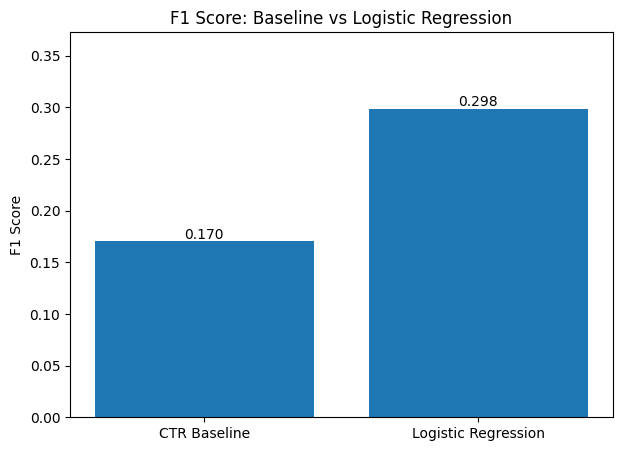

In [85]:
import matplotlib.pyplot as plt

# Model vs baseline F1 comparison

f1_values = [
    results.loc[results["Metric"] == "F1", "CTR Baseline"].iloc[0],
    results.loc[results["Metric"] == "F1", "Logistic Regression"].iloc[0]
]

labels = ["CTR Baseline", "Logistic Regression"]

plt.figure(figsize=(7, 5))
plt.bar(labels, f1_values)

plt.ylabel("F1 Score")
plt.title("F1 Score: Baseline vs Logistic Regression")
plt.ylim(0, max(f1_values) * 1.25)

for i, value in enumerate(f1_values):
    plt.text(i, value, f"{value:.3f}", ha="center", va="bottom")

plt.show()

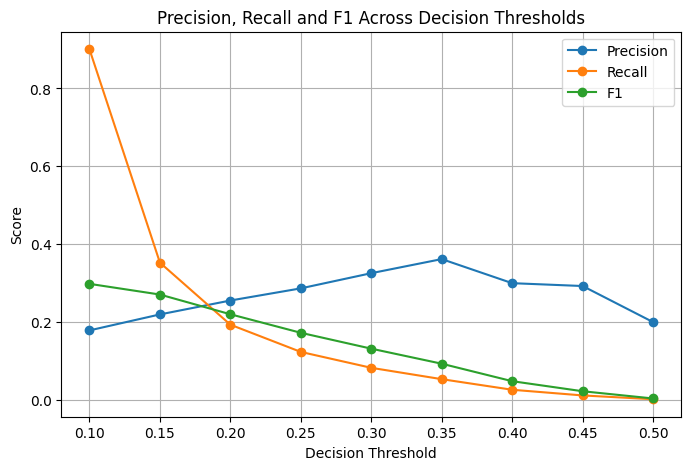

In [86]:
# Threshold analysis: Precision, Recall and F1

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Across Decision Thresholds")
plt.legend()
plt.grid(True)

plt.show()

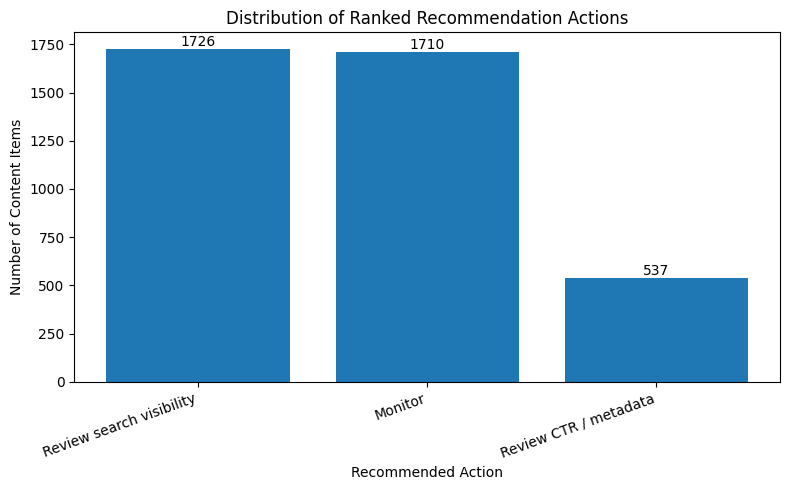

In [87]:
# Recommendation action distribution

plt.figure(figsize=(8, 5))

plt.bar(
    action_summary["recommended_action"],
    action_summary["count"]
)

plt.xlabel("Recommended Action")
plt.ylabel("Number of Content Items")
plt.title("Distribution of Ranked Recommendation Actions")

plt.xticks(rotation=20, ha="right")

for i, value in enumerate(action_summary["count"]):
    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Artifacts Summary

The paper includes three visual artifacts: a comparison of F1 score between the CTR baseline and Logistic Regression, a threshold analysis showing the precision-recall trade-off, and a distribution of the resulting editorial recommendation categories. Together, these artifacts show both the measured model performance and how the model output can be translated into a practical review workflow.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the Paper Embeds

The deployed paper will embed visual artifacts generated from the capstone analysis. These artifacts are designed to make the model performance and recommendation output easier to interpret.

The paper will include:

1. **Model vs baseline chart** — comparison of accuracy, precision, recall, and F1 score for the CTR baseline and Logistic Regression model.

2. **Error analysis chart** — distribution of true positives, true negatives, false positives, and false negatives on the held-out test set.

3. **Recommendation action chart** — number of content items assigned to each editorial action category.

4. **Ranked recommendation table** — a sample of the highest-priority content items showing model score, recommended action, reason code, impressions, CTR, and average search position.

All visualizations are generated from the analysis outputs and use aggregated or pseudonymous information only. No client names, domains, private search queries, credentials, or raw client-identifying information are included.


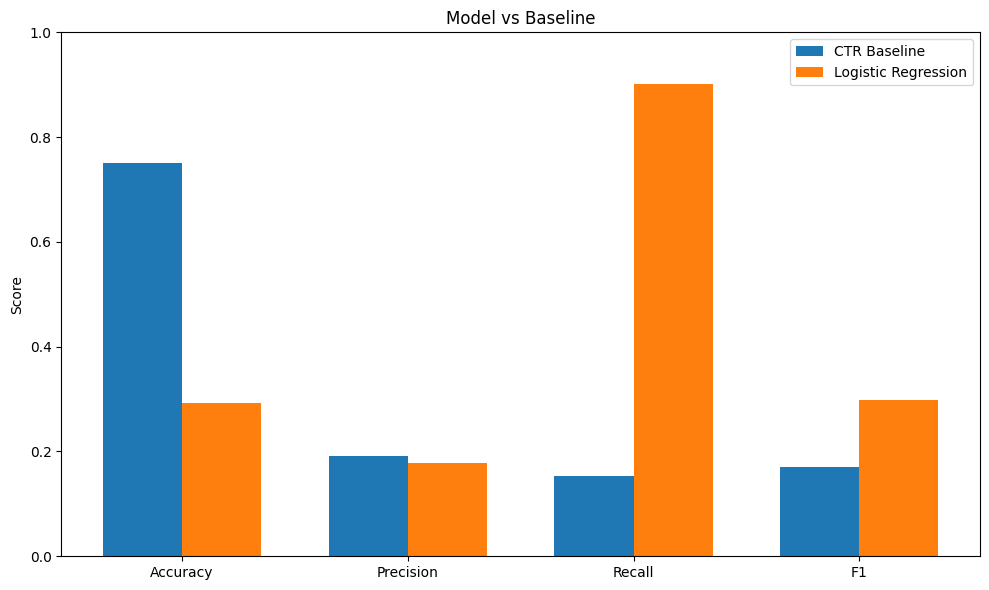

In [88]:
# Section 7 — Artifact 1: Model vs Baseline

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]

baseline_values = [0.7501, 0.1911, 0.1535, 0.1703]
model_values = [0.2922, 0.1787, 0.9009, 0.2983]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    baseline_values,
    width,
    label="CTR Baseline"
)

plt.bar(
    x + width/2,
    model_values,
    width,
    label="Logistic Regression"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model vs Baseline")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()

plt.show()

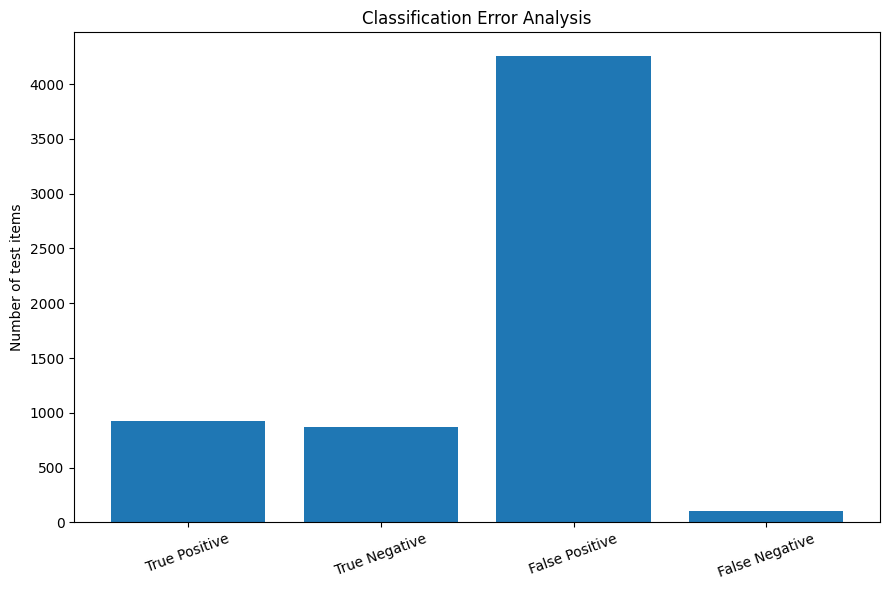

In [89]:
# Section 7 — Artifact 2: Error Analysis

error_counts = {
    "True Positive": 927,
    "True Negative": 874,
    "False Positive": 4260,
    "False Negative": 102
}

plt.figure(figsize=(9, 6))

plt.bar(
    error_counts.keys(),
    error_counts.values()
)

plt.ylabel("Number of test items")
plt.title("Classification Error Analysis")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

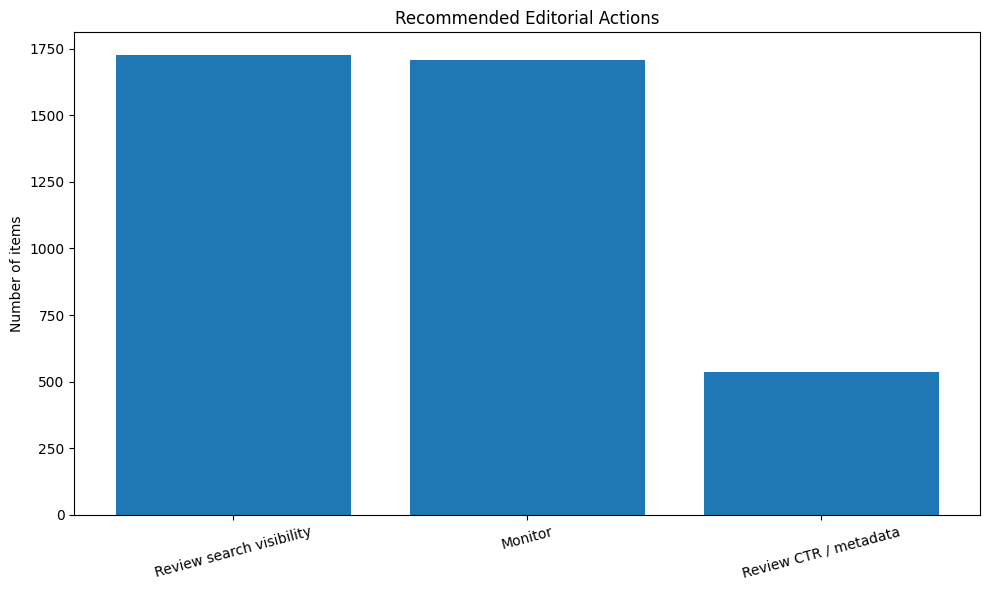

In [90]:
# Section 7 — Artifact 3: Recommendation actions

action_counts = {
    "Review search visibility": 1726,
    "Monitor": 1710,
    "Review CTR / metadata": 537
}

plt.figure(figsize=(10, 6))

plt.bar(
    action_counts.keys(),
    action_counts.values()
)

plt.ylabel("Number of items")
plt.title("Recommended Editorial Actions")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 8. Acknowledgments & Data Credit

This capstone was built on the **FlyRank ML Internship dataset** and developed as part of the FlyRank ML Internship capstone.

The analysis uses anonymized content and client identifiers and follows the public-safety requirements of the internship project. The results are presented as observed and measured evidence for decision support and should not be interpreted as causal claims about search-engine algorithms.

Data source: [FlyRank](https://flyrank.ai)
